In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost.callback import EarlyStopping

In [18]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df_tree = df.copy()
df_tree.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df_tree["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df_tree.drop("customerID", axis = 1, inplace = True)
df_tree.drop("tenure", axis = 1, inplace = True)
df_tree.drop("MonthlyCharges", axis = 1, inplace = True)
df_tree.drop("TotalCharges", axis = 1, inplace = True)


In [11]:
df_tree = pd.get_dummies(df_tree, drop_first=True)
df_tree.head()

,SeniorCitizen,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,False,True,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,0,True,False,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,1,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,0,True,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,1,False,False,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [12]:
x = df_tree.drop("Churn", axis = 1)
y = df_tree["Churn"]

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 1, stratify = y)

In [14]:
min_samples_split_list = [50, 100, 200, 300, 400,700, 850]                                            
max_depth_list = [2, 4, 8, 16, 32, 64, None]
n_estimators_list = [10,50,100,500]

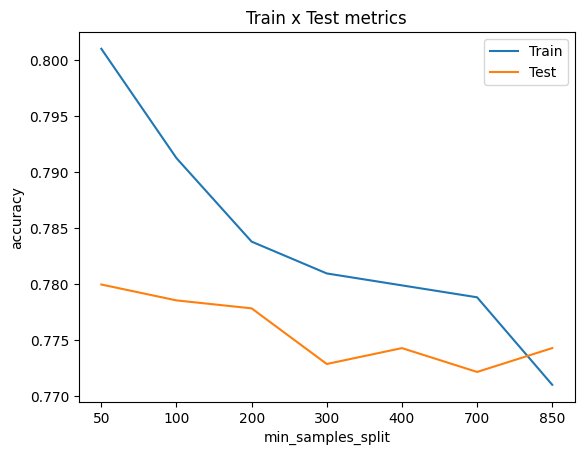

In [15]:
accuracy_list_train = []
accuracy_list_test = []
for min_samples_split in min_samples_split_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(min_samples_split = min_samples_split,
                                   random_state = 1).fit(x_train,y_train) 
    predictions_train = model.predict(x_train) ## The predicted values for the train dataset
    predictions_test = model.predict(x_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list) 
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

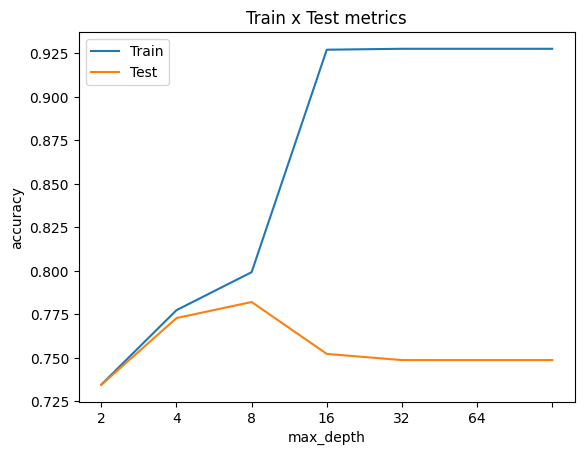

In [16]:
accuracy_list_train = []
accuracy_list_test = []
for max_depth in max_depth_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(max_depth = max_depth,
                                   random_state = 1).fit(x_train,y_train) 
    predictions_train = model.predict(x_train) ## The predicted values for the train dataset
    predictions_test = model.predict(x_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

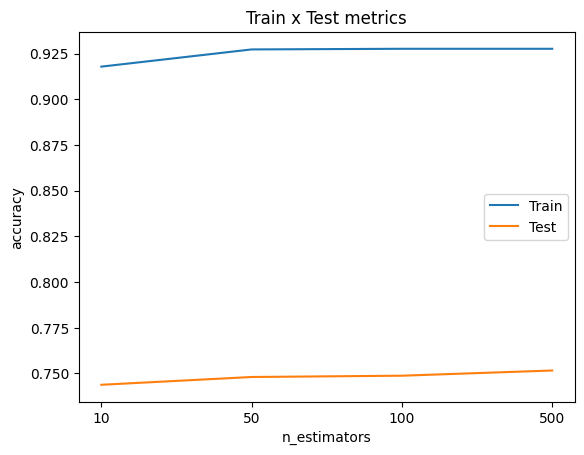

In [19]:
accuracy_list_train = []
accuracy_list_test = []
for n_estimators in n_estimators_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(n_estimators = n_estimators,
                                   random_state = 1).fit(x_train,y_train) 
    predictions_train = model.predict(x_train) ## The predicted values for the train dataset
    predictions_test = model.predict(x_test) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_test = accuracy_score(predictions_test,y_test)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_test.append(accuracy_test)

plt.title('Train x Test metrics')
plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(n_estimators_list )),labels=n_estimators_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_test)
plt.legend(['Train','Test'])

In [27]:
random_forest_model = RandomForestClassifier(n_estimators = 50,
                                             max_depth = 4, 
                                             min_samples_split = 775).fit(x_train,y_train)

In [28]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(x_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(x_test),y_test):.4f}")

Metrics train:
	Accuracy score: 0.7746
Metrics test:
	Accuracy score: 0.7722


In [29]:
print(f"Metrics train:\n\tAccuracy score: {classification_report(random_forest_model.predict(x_train),y_train)}\nMetrics test:\n\tAccuracy score: {classification_report(random_forest_model.predict(x_test),y_test)}")

Metrics train:
	Accuracy score:               precision    recall  f1-score   support

           0       0.96      0.78      0.86      5051
           1       0.27      0.69      0.39       583

    accuracy                           0.77      5634
   macro avg       0.61      0.74      0.63      5634
weighted avg       0.89      0.77      0.81      5634

Metrics test:
	Accuracy score:               precision    recall  f1-score   support

           0       0.96      0.78      0.86      1270
           1       0.26      0.69      0.37       139

    accuracy                           0.77      1409
   macro avg       0.61      0.74      0.62      1409
weighted avg       0.89      0.77      0.81      1409



In [52]:
# Applying xg boost

In [45]:

xgb_model = XGBClassifier(
    n_estimators=50,
    learning_rate=0.1,
    random_state=1,
    eval_metric="logloss",
    early_stopping_rounds=50,
    scale_pos_weight=2.7
)

xgb_model.fit(
    x_train,
    y_train,
    eval_set=[(x_test, y_test)],
    verbose=True
)


[0]	validation_0-logloss:0.65775
[1]	validation_0-logloss:0.63376
[2]	validation_0-logloss:0.61444
[3]	validation_0-logloss:0.59838
[4]	validation_0-logloss:0.58563
[5]	validation_0-logloss:0.57484
[6]	validation_0-logloss:0.56618
[7]	validation_0-logloss:0.55902
[8]	validation_0-logloss:0.55263
[9]	validation_0-logloss:0.54761
[10]	validation_0-logloss:0.54354
[11]	validation_0-logloss:0.54019
[12]	validation_0-logloss:0.53688
[13]	validation_0-logloss:0.53439
[14]	validation_0-logloss:0.53239
[15]	validation_0-logloss:0.53031
[16]	validation_0-logloss:0.52871
[17]	validation_0-logloss:0.52715
[18]	validation_0-logloss:0.52660
[19]	validation_0-logloss:0.52592
[20]	validation_0-logloss:0.52544
[21]	validation_0-logloss:0.52526
[22]	validation_0-logloss:0.52484
[23]	validation_0-logloss:0.52462
[24]	validation_0-logloss:0.52393
[25]	validation_0-logloss:0.52372
[26]	validation_0-logloss:0.52368
[27]	validation_0-logloss:0.52359
[28]	validation_0-logloss:0.52353
[29]	validation_0-loglos

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [46]:
xgb_model.best_iteration

33

In [47]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(xgb_model.predict(x_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(xgb_model.predict(x_test),y_test):.4f}")

Metrics train:
	Accuracy score: 0.7698
Metrics test:
	Accuracy score: 0.7182


In [48]:
print(f"Metrics train:\n{classification_report(y_train, xgb_model.predict(x_train))}")
print(f"Metrics test:\n{classification_report(y_test, xgb_model.predict(x_test))}")

Metrics train:
              precision    recall  f1-score   support

           0       0.93      0.75      0.83      4139
           1       0.54      0.84      0.66      1495

    accuracy                           0.77      5634
   macro avg       0.74      0.79      0.74      5634
weighted avg       0.83      0.77      0.78      5634

Metrics test:
              precision    recall  f1-score   support

           0       0.89      0.70      0.79      1035
           1       0.48      0.76      0.59       374

    accuracy                           0.72      1409
   macro avg       0.69      0.73      0.69      1409
weighted avg       0.78      0.72      0.73      1409



In [53]:
import joblib
joblib.dump(xgb_model, "dt_model.joblib")

['dt_model.joblib']